<a href="https://colab.research.google.com/github/rafi-shoishab/CSE715-VAE-Music-Clustering/blob/main/CSE715_VAE_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import torch
print(torch.cuda.is_available())

True


In [11]:
import librosa
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [12]:
!pip install librosa tqdm

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
os.listdir("/content/drive/MyDrive/CSE715/GTZAN")

['Data']

In [15]:
DATA_PATH = "/content/drive/MyDrive/CSE715/GTZAN/Data/genres_original"

In [16]:
os.listdir(DATA_PATH)

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [17]:
def extract_mfcc(file_path):
    y, sr = librosa.load(file_path, duration=30)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfcc.T, axis=0)

In [18]:
X = []
y = []

for genre in os.listdir(DATA_PATH):

    genre_path = os.path.join(DATA_PATH, genre)

    # ✅ skip non-directories (.DS_Store etc.)
    if not os.path.isdir(genre_path):
        continue

    for file in tqdm(os.listdir(genre_path)):
        file_path = os.path.join(genre_path, file)

        try:
            mfcc = extract_mfcc(file_path)
            X.append(mfcc)
            y.append(genre)
        except:
            pass

X = np.array(X)

 52%|█████▏    | 53/101 [00:38<00:36,  1.31it/s]/tmp/ipykernel_14000/503129895.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 100/100 [01:15<00:00,  1.33it/s]


In [19]:
X.shape

(1000, 40)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled[:2]

array([[ 1.3631965 , -1.1760701 ,  0.34450656, -0.49219185,  0.9111621 ,
        -0.44741094,  1.0626385 , -0.02944194,  1.2120461 ,  0.08721845,
         0.9303211 ,  0.30754244,  0.89828473, -0.71099997,  0.9707983 ,
         0.40002552,  0.26401147,  0.5982468 ,  0.15578757,  0.5388556 ,
         0.21636362, -1.0766402 , -0.5055392 ,  0.03354941, -0.7702123 ,
         0.63828224,  0.31588134, -0.26082873, -0.08721427,  0.26220775,
        -2.2259936 , -1.6053209 , -1.5128615 , -0.23056103, -0.10130873,
        -0.60791296, -0.20359622, -0.10031717, -0.8396651 ,  0.18371712],
       [ 1.2117177 , -0.93555915,  0.5878968 , -0.47939014,  1.2215676 ,
        -0.7539984 ,  0.9176146 , -0.25638875,  1.1663147 ,  0.09581425,
         0.5491388 , -0.35753477,  0.23085006,  0.66619265,  0.759947  ,
        -0.17317645,  1.0007861 ,  0.9099198 ,  0.8665438 ,  1.3514391 ,
        -0.23264961, -0.05581791, -0.6167249 ,  0.5852062 ,  0.33582518,
         1.6642812 , -0.26279923,  0.40009472,  0.

In [22]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

print(device)

cuda


In [23]:
import torch.nn as nn

In [24]:
class VAE(nn.Module):

    def __init__(self, input_dim=40, latent_dim=8):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Latent parameters
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [25]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [26]:
def loss_fn(recon, x, mu, logvar):

    recon_loss = ((recon - x) ** 2).mean()

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu**2 - logvar.exp()
    )

    return recon_loss + kl_loss

In [27]:
for epoch in range(50):

    optimizer.zero_grad()

    recon, mu, logvar = model(X_tensor)

    loss = loss_fn(recon, X_tensor, mu, logvar)

    loss.backward()
    optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.0253949165344238
Epoch: 1 Loss: 1.0231207609176636
Epoch: 2 Loss: 1.0190662145614624
Epoch: 3 Loss: 1.0164921283721924
Epoch: 4 Loss: 1.0152592658996582
Epoch: 5 Loss: 1.0133000612258911
Epoch: 6 Loss: 1.0118221044540405
Epoch: 7 Loss: 1.0115058422088623
Epoch: 8 Loss: 1.0096617937088013
Epoch: 9 Loss: 1.0076513290405273
Epoch: 10 Loss: 1.008127212524414
Epoch: 11 Loss: 1.0070290565490723
Epoch: 12 Loss: 1.0061794519424438
Epoch: 13 Loss: 1.0052767992019653
Epoch: 14 Loss: 1.0056602954864502
Epoch: 15 Loss: 1.0050421953201294
Epoch: 16 Loss: 1.0052056312561035
Epoch: 17 Loss: 1.0047483444213867
Epoch: 18 Loss: 1.0038647651672363
Epoch: 19 Loss: 1.003281831741333
Epoch: 20 Loss: 1.0041824579238892
Epoch: 21 Loss: 1.004837989807129
Epoch: 22 Loss: 1.0030161142349243
Epoch: 23 Loss: 1.0029202699661255
Epoch: 24 Loss: 1.0040132999420166
Epoch: 25 Loss: 1.0032588243484497
Epoch: 26 Loss: 1.0028502941131592
Epoch: 27 Loss: 1.0015095472335815
Epoch: 28 Loss: 1.002589106559753

In [28]:
with torch.no_grad():
    h = model.encoder(X_tensor)
    z = model.mu(h).cpu().numpy()

z.shape

(1000, 8)

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(z)

In [30]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

sil = silhouette_score(z, labels)
ch = calinski_harabasz_score(z, labels)

print("Silhouette Score:", sil)
print("Calinski-Harabasz:", ch)

Silhouette Score: 0.15513614
Calinski-Harabasz: 309.18112


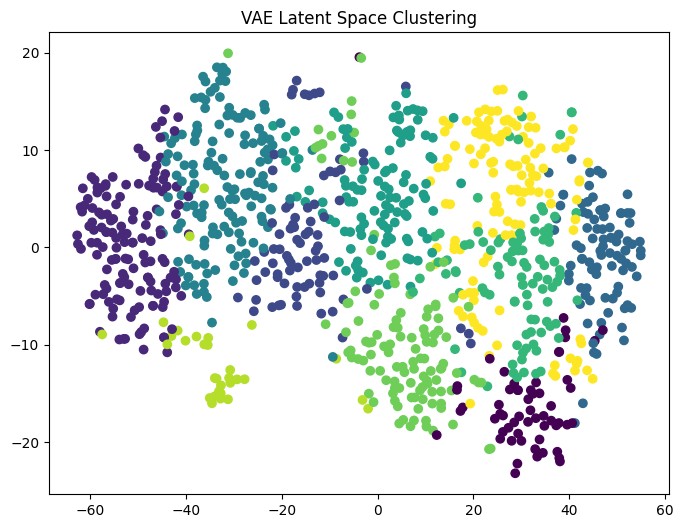

In [31]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

z_2d = TSNE(n_components=2, random_state=42).fit_transform(z)

plt.figure(figsize=(8,6))
plt.scatter(z_2d[:,0], z_2d[:,1], c=labels)
plt.title("VAE Latent Space Clustering")
plt.show()

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
DATA_PATH = "/content/drive/MyDrive/CSE715/GTZAN/Data/genres_original"

In [34]:
import os
os.listdir(DATA_PATH)

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [35]:
import os
import numpy as np
import librosa
from tqdm import tqdm

In [36]:
DATA_PATH = "/content/drive/MyDrive/CSE715/GTZAN/Data/genres_original"

In [37]:
os.listdir(DATA_PATH)

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [38]:
genres = os.listdir(DATA_PATH)
genres

['country',
 'hiphop',
 'rock',
 'jazz',
 'classical',
 'disco',
 'reggae',
 'blues',
 'metal',
 'pop']

In [39]:
X = []
y = []

In [40]:
for genre in genres:

    if genre.startswith("."):
        continue

    genre_path = os.path.join(DATA_PATH, genre)

    if not os.path.isdir(genre_path):
        continue

    for file in tqdm(os.listdir(genre_path)):

        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(genre_path, file)

        try:
            signal, sr = librosa.load(file_path, duration=30)

            mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
            mfcc_mean = np.mean(mfcc.T, axis=0)

            X.append(mfcc_mean)
            y.append(genre)

        except Exception as e:
            print(f"Skipping corrupted file: {file}")
            continue

X = np.array(X)
y = np.array(y)

 50%|█████     | 51/101 [00:02<00:02, 19.11it/s]/tmp/ipykernel_14000/3822473961.py:19: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 56%|█████▋    | 57/101 [00:03<00:02, 15.19it/s]

Skipping corrupted file: jazz.00054.wav


100%|██████████| 100/100 [00:06<00:00, 16.02it/s]


In [41]:
print(X.shape)
print(len(y))

(1000, 40)
1000


In [42]:
import pandas as pd
os.makedirs("results", exist_ok=True)

df = pd.DataFrame(X)
df["label"] = y

df.to_csv("results/features.csv", index=False)

In [43]:
os.listdir("results")

['features.csv']

In [44]:
print(X.shape)
os.listdir("results")

(1000, 40)


['features.csv']

In [ ]:
# medium task